# Unsupervised GMM clustering — welded CR-39 tracks

Same pipeline as [`gmm_nn_unsup_4.py`](gmm_nn_unsup_4.py): ROI threshold → morphological closing (welding) → contour features → GMM.

This notebook adds **full per-cluster statistics** and **evaluation plots** (montages, t-SNE, silhouette, spatial overlays) modelled on Step 3 of `algorithms/radon_track_nn.ipynb`.

## Step 0 — Setup, configuration and image I/O

In [ ]:
import sys
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

GMM_DIR = Path.cwd() if (Path.cwd() / "gmm_nn_unsup_4.py").exists() else Path.cwd() / "gmm"
if str(GMM_DIR) not in sys.path:
    sys.path.insert(0, str(GMM_DIR))

from gmm_nn_unsup_4 import (
    Config,
    extract_features_from_roi,
    cluster_colors_rgb,
    cluster_norm,
    contour_centroid,
    contour_max_intensity,
    meta_row_from_contour,
    apply_watershed_pass,
    compare_watershed_methods,
    suggest_artifact_clusters,
    resolve_ws_clusters,
    load_macro_counts,
    build_count_comparison,
    save_count_comparison_plots,
    plot_roi_three_variants,
    roi_window_counts,
)

cfg = Config()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

PATCH_SIZE = 48 # 48 pixels
MONTAGE_N = 24
MONTAGE_COLS = 8
ROI_WINDOW = 700
# Fixed ROI for cross-run comparison (5.6b)
COMPARE_ROI_IMAGE = "LBS255612.jpg"
COMPARE_ROI_X0 = 200
COMPARE_ROI_Y0 = 400
FOCUS_CLUSTER = 1  # single-cluster spatial plot after fig2
FOCUS_CMAP = "turbo"  # continuous colormap; scales to large event counts
CLUSTER_CMAP = "turbo"  # continuous colormap for cluster id 0..K-1

# Step 6 — watershed + artifact tagging
WS_MIN_AREA = 160
WS_MIN_FRAGMENT_AREA = 20
WS_CLUSTER_FILTER = False
WATERSHED_CLUSTERS = None  # empty => auto from mean area >= WS_MIN_AREA 
WS_METHOD = "distance_peaks"
ARTIFACT_CLUSTERS = None  # None => saliency heuristic; or e.g. [0, 4, 5]

# Visual comparison ROI (usual field of view)
VISUAL_COMPARE_ROI_IMAGE = "LBS255611.jpg"
VISUAL_COMPARE_ROI_X0 = 700
VISUAL_COMPARE_ROI_Y0 = 1400
VISUAL_COMPARE_ROI_SIZE = 700

np.random.seed(cfg.random_state)

image_paths = sorted(cfg.data_dir.glob(cfg.image_glob))
print(f"data_dir: {cfg.data_dir}")
print(f"output_dir: {cfg.output_dir}")
print(f"images: {len(image_paths)} matching {cfg.image_glob}")
if image_paths:
    print("  first:", image_paths[0].name)

data_dir: /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/data_test
output_dir: /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs
images: 15 matching LBS*.jpg
  first: LBS255611.jpg


## Step 1 — Feature extraction (welded contours + event registry)

In [2]:
if not image_paths:
    raise FileNotFoundError(f"No files matching {cfg.image_glob} in {cfg.data_dir}")

print("Extracting physical features with spatial coalescence (welding)...")
all_features = []
meta_rows = []
image_registry = []
label_offset = 0

for path in image_paths:
    print(f"  Scanning {path.name}...")
    feats, cnts, roi, debug_thresh = extract_features_from_roi(path, cfg)
    if feats is None:
        continue
    print(f"    -> Extracted {len(feats)} valid events (Area >= {cfg.min_area}px).")
    if cfg.save_debug_images and debug_thresh is not None:
        cv2.imwrite(str(cfg.output_dir / f"debug_binary_{path.stem}.png"), debug_thresh)
    if len(feats) == 0:
        continue
    for i, cnt in enumerate(cnts):
        meta_rows.append(meta_row_from_contour(path.name, roi, cnt))
    all_features.append(feats)
    image_registry.append({
        "path": path,
        "counts": len(feats),
        "label_start": label_offset,
        "contours": cnts,
        "roi": roi,
    })
    label_offset += len(feats)

if not all_features:
    raise RuntimeError("CRITICAL ZERO COUNT: The signal is completely empty.")

X = np.vstack(all_features)
meta = pd.DataFrame(meta_rows)
assert len(meta) == len(X)
print(f"\nTotal physical events across {len(image_registry)} images: {len(X)}")

Extracting physical features with spatial coalescence (welding)...
  Scanning LBS255611.jpg...
    -> Extracted 942 valid events (Area >= 20.0px).
  Scanning LBS255612.jpg...
    -> Extracted 859 valid events (Area >= 20.0px).
  Scanning LBS255613.jpg...
    -> Extracted 842 valid events (Area >= 20.0px).
  Scanning LBS255614.jpg...
    -> Extracted 819 valid events (Area >= 20.0px).
  Scanning LBS255615.jpg...
    -> Extracted 828 valid events (Area >= 20.0px).
  Scanning LBS255616.jpg...
    -> Extracted 719 valid events (Area >= 20.0px).
  Scanning LBS255617.jpg...
    -> Extracted 935 valid events (Area >= 20.0px).
  Scanning LBS255618.jpg...
    -> Extracted 767 valid events (Area >= 20.0px).
  Scanning LBS255619.jpg...
    -> Extracted 863 valid events (Area >= 20.0px).
  Scanning LBS255620.jpg...
    -> Extracted 932 valid events (Area >= 20.0px).
  Scanning LBS255621.jpg...
    -> Extracted 882 valid events (Area >= 20.0px).
  Scanning LBS255622.jpg...
    -> Extracted 978 vali

## Step 2 — GMM fit and script-parity exports

Fitting Gaussian Mixture Model with k=8 classes...

cluster sizes:
cluster
0    2400
1     823
2    1776
3       4
4    3120
5    4768
6       1
7     211
Name: count, dtype: int64


/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

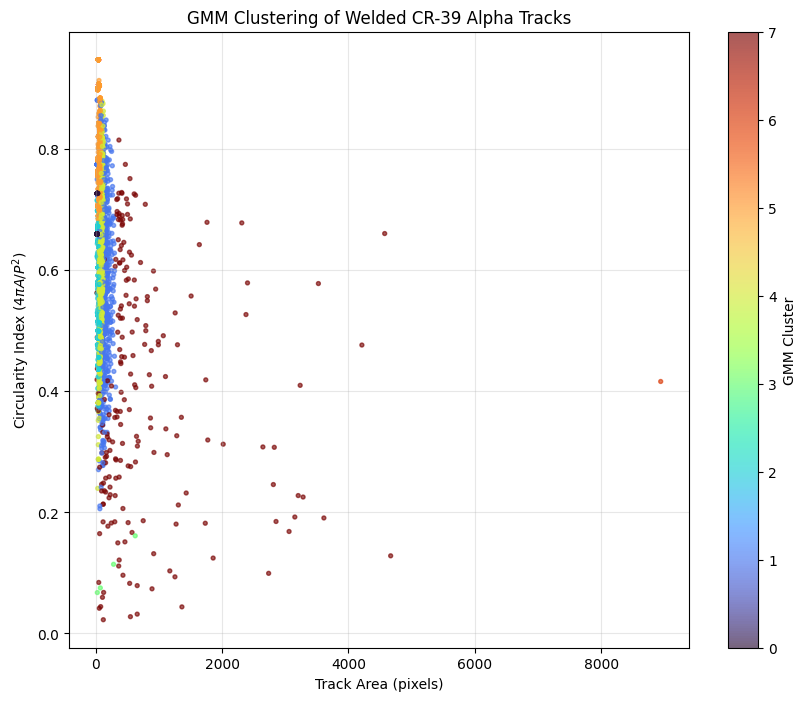

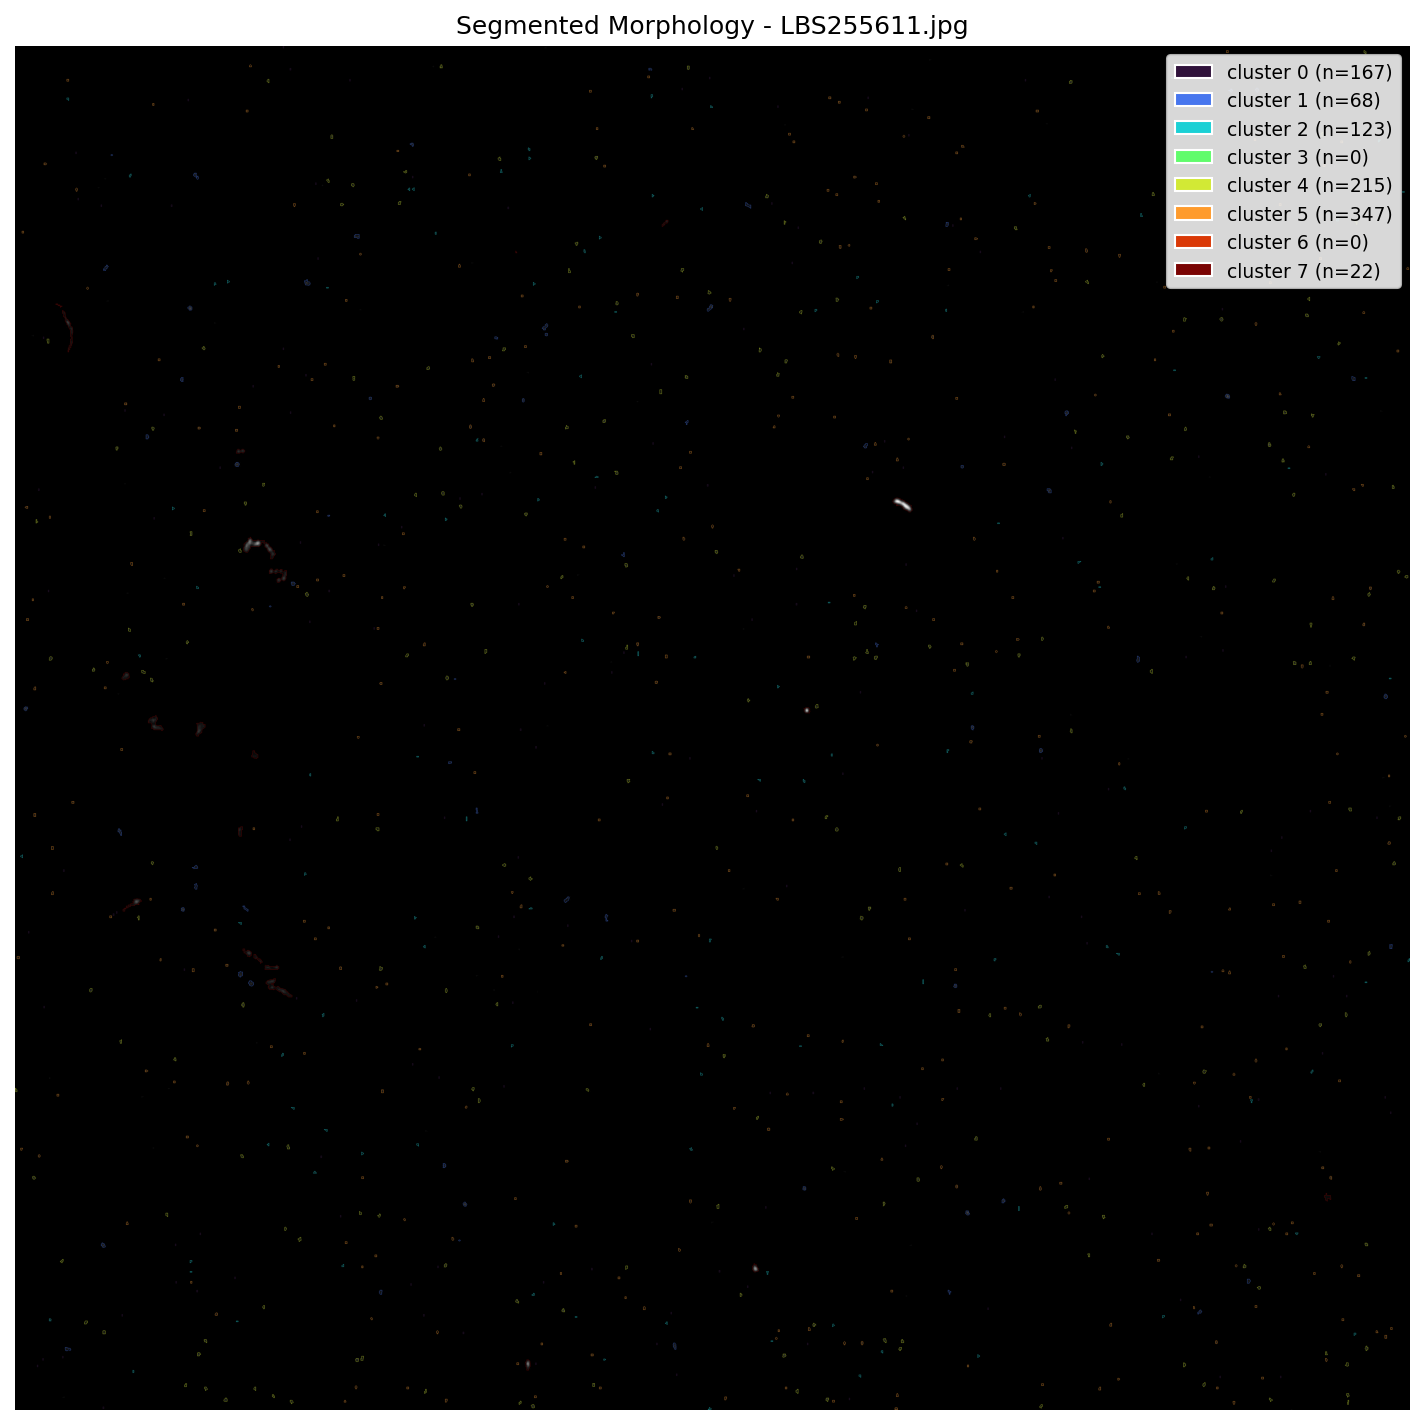

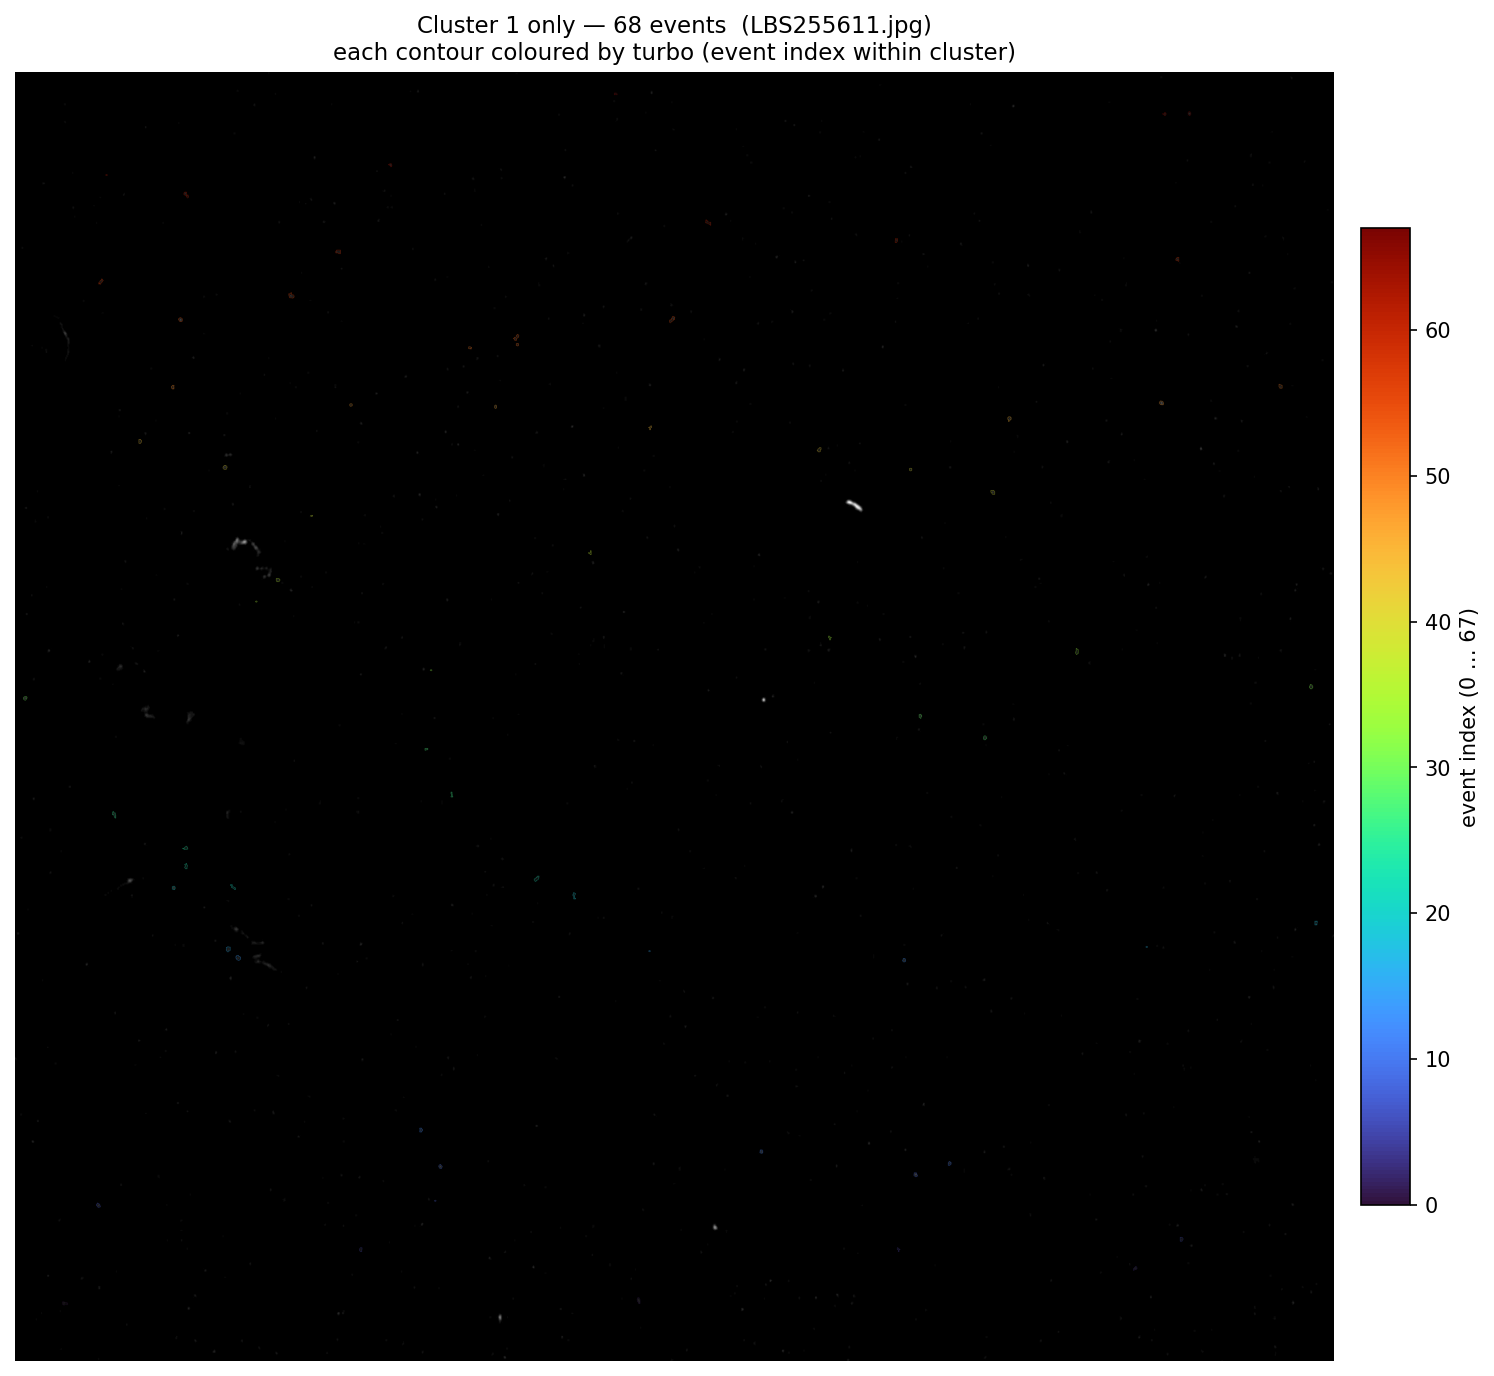

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs/fig2_spatial_mapping_cluster1.png  (68 events)
Saved gmm_model.joblib, fig1, fig2, gmm_cluster_profiles.csv → /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Fitting Gaussian Mixture Model with k={cfg.n_clusters} classes...")
gmm = GaussianMixture(
    n_components=cfg.n_clusters,
    covariance_type="full",
    random_state=cfg.random_state,
)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)
posterior = gmm.predict_proba(X_scaled)

meta = meta.copy()
meta["cluster"] = labels
meta["posterior"] = posterior[np.arange(len(labels)), labels]
meta_gmm = meta.copy()
K = cfg.n_clusters

print("\ncluster sizes:")
print(meta["cluster"].value_counts().sort_index())

# Cluster colours: continuous colormap sampled at ids 0..K-1
colors_rgb = cluster_colors_rgb(K, CLUSTER_CMAP)
colors_bgr = [
    (int(b * 255), int(g * 255), int(r * 255)) for r, g, b in colors_rgb
]
_cluster_cmap = plt.colormaps[CLUSTER_CMAP]
_cluster_norm = cluster_norm(K)

# Fig 1: feature space (area vs circularity)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X[:, 0],
    X[:, 2],
    c=labels,
    cmap=_cluster_cmap,
    norm=_cluster_norm,
    alpha=0.65,
    s=8,
)
plt.xlabel("Track Area (pixels)")
plt.ylabel(r"Circularity Index ($4\pi A / P^2$)")
plt.title("GMM Clustering of Welded CR-39 Alpha Tracks")
plt.colorbar(scatter, label="GMM Cluster", ticks=list(range(K)))
plt.grid(True, alpha=0.3)
plt.savefig(cfg.output_dir / "fig1_feature_space.pdf", bbox_inches="tight")
plt.show()

# Minimal cluster profiles (script parity)
profile_rows = []
for cluster_id in range(K):
    mask = labels == cluster_id
    cluster_feats = X[mask]
    if len(cluster_feats) > 0:
        profile_rows.append({
            "cluster_id": cluster_id,
            "event_count": len(cluster_feats),
            "mean_area_px": float(np.mean(cluster_feats[:, 0])),
            "mean_circularity": float(np.mean(cluster_feats[:, 2])),
            "mean_aspect_ratio": float(np.mean(cluster_feats[:, 3])),
        })
pd.DataFrame(profile_rows).to_csv(cfg.output_dir / "gmm_cluster_profiles.csv", index=False)

# Fig 2: spatial mapping on first image (same cluster colours as fig1)
if image_registry:
    sample = image_registry[0]
    start = sample["label_start"]
    end = start + sample["counts"]
    sample_labels = labels[start:end]
    roi_norm = cv2.normalize(sample["roi"], None, 0, 255, cv2.NORM_MINMAX)
    roi_color = cv2.cvtColor(roi_norm, cv2.COLOR_GRAY2BGR)
    for idx, cnt in enumerate(sample["contours"]):
        c_id = sample_labels[idx]
        cv2.drawContours(roi_color, [cnt], -1, colors_bgr[c_id], 1)
    plt.figure(figsize=(12, 12), dpi=150)
    plt.imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
    plt.title(f"Segmented Morphology - {sample['path'].name}")
    plt.axis("off")
    legend_handles = [
        Patch(
            facecolor=colors_rgb[c],
            edgecolor="white",
            label=f"cluster {c} (n={int((sample_labels == c).sum())})",
        )
        for c in range(K)
    ]
    plt.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.85)
    plt.savefig(cfg.output_dir / "fig2_spatial_mapping.png", bbox_inches="tight")
    plt.show()

    # Fig 2b: one cluster only — each event gets a distinct colormap colour
    focus_idx = np.where(sample_labels == FOCUS_CLUSTER)[0]
    n_focus = len(focus_idx)
    if n_focus == 0:
        print(f"No cluster-{FOCUS_CLUSTER} events on {sample['path'].name}; skip focus plot.")
    else:
        roi_focus = cv2.cvtColor(roi_norm, cv2.COLOR_GRAY2BGR)
        cmap = plt.get_cmap(FOCUS_CMAP)
        for rank, idx in enumerate(focus_idx):
            t = rank / max(n_focus - 1, 1)
            r, g, b, _ = cmap(t)
            bgr = (int(b * 255), int(g * 255), int(r * 255))
            cv2.drawContours(roi_focus, [sample["contours"][idx]], -1, bgr, 1)
        fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
        ax.imshow(cv2.cvtColor(roi_focus, cv2.COLOR_BGR2RGB))
        ax.set_title(
            f"Cluster {FOCUS_CLUSTER} only — {n_focus} events  ({sample['path'].name})\n"
            f"each contour coloured by {FOCUS_CMAP} (event index within cluster)",
            fontsize=11,
        )
        ax.axis("off")
        sm = plt.cm.ScalarMappable(
            cmap=cmap,
            norm=plt.Normalize(vmin=0, vmax=max(n_focus - 1, 1)),
        )
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
        cbar.set_label(f"event index (0 … {n_focus - 1})")
        focus_path = cfg.output_dir / f"fig2_spatial_mapping_cluster{FOCUS_CLUSTER}.png"
        fig.savefig(focus_path, bbox_inches="tight")
        plt.show()
        print(f"Saved {focus_path}  ({n_focus} events)")

joblib.dump({"scaler": scaler, "gmm": gmm}, cfg.output_dir / "gmm_model.joblib")
print(f"Saved gmm_model.joblib, fig1, fig2, gmm_cluster_profiles.csv → {cfg.output_dir}")

## Step 3 — Full per-cluster statistics

,n,pct_total,n_images,area_min,area_mean,area_max,area_std,perimeter_min,perimeter_mean,perimeter_max,...,aspect_ratio_min,aspect_ratio_mean,aspect_ratio_max,aspect_ratio_std,max_intensity_min,max_intensity_mean,max_intensity_max,max_intensity_std,posterior_mean,posterior_min
cluster,,,,,,,,,,,,,,,,,,,,,
0,2400,18.316,15,21.0,21.718,28.0,2.124,20.000,20.205,22.000,...,0.500,0.513,0.625,0.038,1.0,1.004,2.0,0.064,1.000,1.000
1,823,6.281,15,22.5,129.592,313.0,57.831,19.071,51.812,98.284,...,0.333,0.952,2.000,0.321,1.0,3.617,14.0,1.913,0.946,0.501
2,1776,13.554,15,21.0,39.476,72.5,9.576,19.657,29.384,46.243,...,0.250,1.012,3.000,0.533,1.0,1.852,4.0,0.522,0.981,0.464
3,4,0.031,2,24.0,250.250,624.0,273.006,66.828,143.192,220.485,...,10.250,12.538,16.500,2.928,1.0,6.500,21.0,9.678,1.000,1.000
4,3120,23.811,15,30.0,80.715,122.5,15.519,31.657,40.650,51.314,...,0.375,0.772,1.231,0.153,1.0,2.867,7.0,0.958,0.964,0.370
5,4768,36.389,15,30.0,52.063,79.5,11.153,20.485,28.748,37.071,...,0.571,0.925,1.500,0.186,1.0,1.840,5.0,0.731,0.978,0.530
6,1,0.008,1,8942.0,8942.000,8942.0,NaN,519.539,519.539,519.539,...,0.585,0.585,0.585,NaN,14.0,14.000,14.0,NaN,1.000,1.000
7,211,1.610,15,20.0,741.145,4667.5,870.845,21.657,155.579,676.233,...,0.016,1.158,5.000,0.909,1.0,10.024,71.0,11.560,0.981,0.529


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,total
image,,,,,,,,,
LBS255611.jpg,167,68,123,0,215,347,0,22,942
LBS255612.jpg,165,48,124,0,196,309,0,17,859
LBS255613.jpg,153,52,111,0,204,306,0,16,842
LBS255614.jpg,166,57,114,0,164,308,0,10,819
LBS255615.jpg,179,55,105,0,192,290,0,7,828
LBS255616.jpg,156,37,103,0,154,263,1,5,719
LBS255617.jpg,152,58,120,0,253,346,0,6,935
LBS255618.jpg,140,47,103,0,181,284,0,12,767
LBS255619.jpg,179,50,137,0,176,304,0,17,863


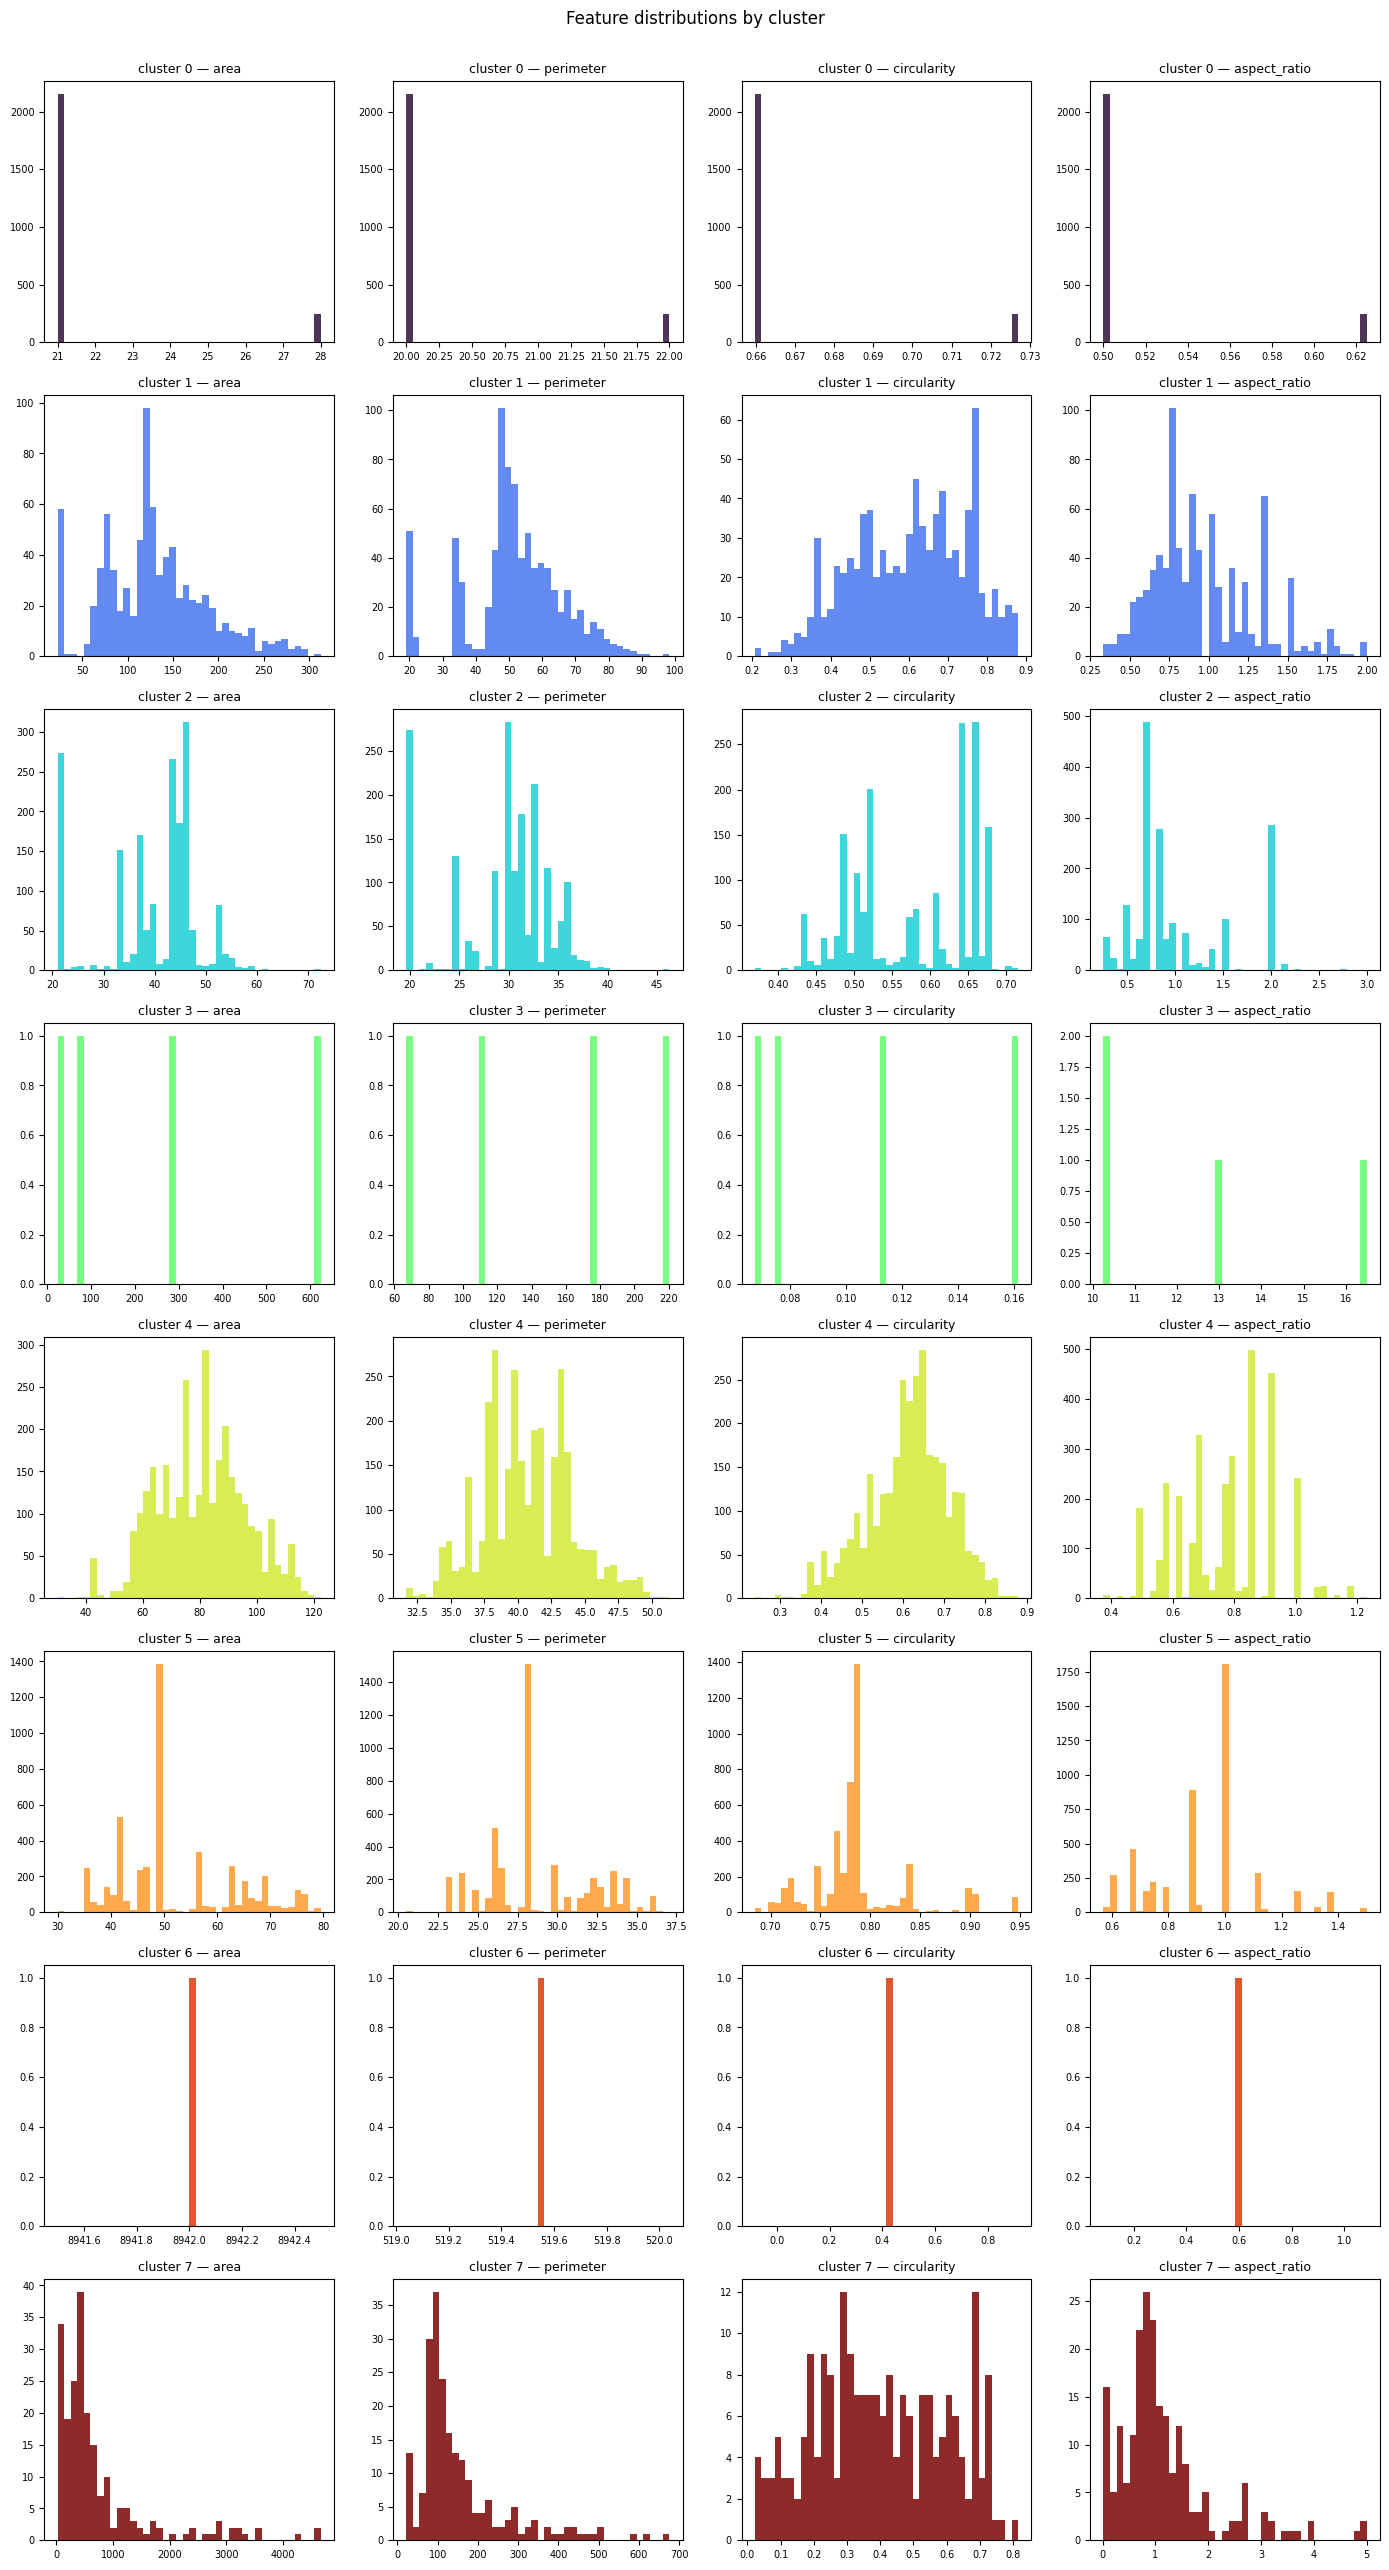

Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs/gmm_cluster_profiles_full.csv


In [4]:
FEATURE_COLS = ["area", "perimeter", "circularity", "aspect_ratio"]
STATS_COLS = FEATURE_COLS + ["max_intensity"]
N_TOTAL = len(meta)


def cluster_stats_block(sub, cluster_id):
    """Monospace summary text + flat dict for CSV."""
    n = len(sub)
    pct = 100.0 * n / N_TOTAL if N_TOTAL else 0.0
    n_images = sub["image"].nunique() if n else 0
    lines = [
        f"cluster={cluster_id}  n={n}  ({pct:.1f}% of all)  images={n_images}",
    ]
    row = {
        "cluster": cluster_id,
        "n": n,
        "pct_total": pct,
        "n_images": n_images,
    }
    if n == 0:
        lines.append("(empty cluster)")
        row["posterior_mean"] = np.nan
        row["posterior_min"] = np.nan
        for col in STATS_COLS:
            for stat in ("min", "mean", "max", "std"):
                row[f"{col}_{stat}"] = np.nan
        return "\n".join(lines), row
    for col in STATS_COLS:
        lines.append(
            f"{col:14s} min={sub[col].min():.3f}  mean={sub[col].mean():.3f}  "
            f"max={sub[col].max():.3f}  std={sub[col].std():.3f}"
        )
        row[f"{col}_min"] = float(sub[col].min())
        row[f"{col}_mean"] = float(sub[col].mean())
        row[f"{col}_max"] = float(sub[col].max())
        row[f"{col}_std"] = float(sub[col].std())
    row["posterior_mean"] = float(sub["posterior"].mean())
    row["posterior_min"] = float(sub["posterior"].min())
    lines.append(
        f"posterior:       min={sub['posterior'].min():.3f}  mean={sub['posterior'].mean():.3f}"
    )
    return "\n".join(lines), row


full_profile_rows = []
for c in range(K):
    sub = meta.loc[meta["cluster"] == c]
    _, row = cluster_stats_block(sub, c)
    full_profile_rows.append(row)

profiles_full_df = pd.DataFrame(full_profile_rows).set_index("cluster").sort_index()
profiles_full_df.to_csv(cfg.output_dir / "gmm_cluster_profiles_full.csv")
display(profiles_full_df.round(3))

# Per-image cluster counts
pivot = meta.pivot_table(index="image", columns="cluster", aggfunc="size", fill_value=0)
pivot.columns = [f"cluster_{c}" for c in pivot.columns]
pivot["total"] = pivot.sum(axis=1)
display(pivot)

# Feature histograms per cluster
fig, axes = plt.subplots(K, 4, figsize=(14, 3.2 * K), squeeze=False)
for c in range(K):
    sub = meta.loc[meta["cluster"] == c]
    for j, col in enumerate(FEATURE_COLS):
        ax = axes[c, j]
        if len(sub):
            ax.hist(sub[col], bins=40, color=colors_rgb[c], alpha=0.85, edgecolor="none")
        ax.set_title(f"cluster {c} — {col}", fontsize=9)
        ax.tick_params(labelsize=7)
plt.suptitle("Feature distributions by cluster", y=1.002)
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_cluster_histograms.pdf", bbox_inches="tight")
plt.show()
print("Saved", cfg.output_dir / "gmm_cluster_profiles_full.csv")

## Step 4 — Patch extraction for montages

In [5]:
half = PATCH_SIZE // 2
roi_by_image = {reg["path"].name: reg["roi"] for reg in image_registry}

patches_raw = []
patch_valid = []
for _, row in meta.iterrows():
    roi = roi_by_image[row["image"]]
    H, W = roi.shape
    cy, cx = int(row["cy"]), int(row["cx"])
    y0, x0 = cy - half, cx - half
    if y0 < 0 or x0 < 0 or y0 + PATCH_SIZE > H or x0 + PATCH_SIZE > W:
        patches_raw.append(None)
        patch_valid.append(False)
        continue
    patch = roi[y0 : y0 + PATCH_SIZE, x0 : x0 + PATCH_SIZE].astype(np.float32)
    patches_raw.append(patch)
    patch_valid.append(True)

meta["patch_valid"] = patch_valid
valid_idx = np.where(meta["patch_valid"].to_numpy())[0]
patches_stack = np.stack([patches_raw[i] for i in valid_idx])
pmax = patches_stack.reshape(len(patches_stack), -1).max(axis=1)
pmax = np.clip(pmax, 1.0, None)
patches_norm = (patches_stack / pmax[:, None, None]).astype(np.float32)
valid_to_global = {j: valid_idx[j] for j in range(len(valid_idx))}
global_to_valid = {valid_idx[j]: j for j in range(len(valid_idx))}
STEP36_RAW_VMAX = max(25, int(np.ceil(float(patches_stack.max()))))
print(f"patches: {len(valid_idx)}/{len(meta)} valid ({PATCH_SIZE}×{PATCH_SIZE})")

patches: 11783/13103 valid (256×256)


## Step 5 — Cluster evaluation plots

/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: 

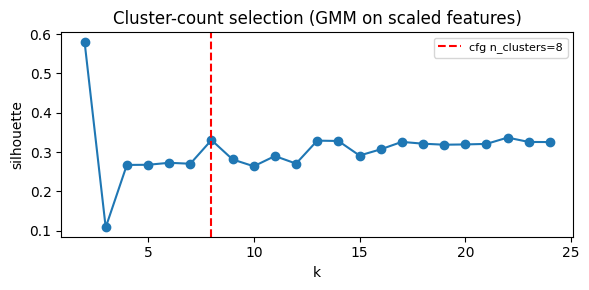

silhouette by k: {2: np.float64(0.581), 3: np.float64(0.109), 4: np.float64(0.267), 5: np.float64(0.268), 6: np.float64(0.273), 7: np.float64(0.27), 8: np.float64(0.331), 9: np.float64(0.281), 10: np.float64(0.264), 11: np.float64(0.29), 12: np.float64(0.271), 13: np.float64(0.329), 14: np.float64(0.328), 15: np.float64(0.291), 16: np.float64(0.307), 17: np.float64(0.326), 18: np.float64(0.321), 19: np.float64(0.319), 20: np.float64(0.319), 21: np.float64(0.321), 22: np.float64(0.337), 23: np.float64(0.326), 24: np.float64(0.325)}


In [6]:
# 5.1 — Silhouette vs k (diagnostic; fit still uses cfg.n_clusters)
ks = range(2, 25)
sil = []
for k in ks:
    gm = GaussianMixture(n_components=k, covariance_type="full", random_state=cfg.random_state)
    gm.fit(X_scaled)
    pred = gm.predict(X_scaled)
    sil.append(silhouette_score(X_scaled, pred, sample_size=min(5000, len(X_scaled)), random_state=cfg.random_state))
plt.figure(figsize=(6, 3))
plt.plot(list(ks), sil, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.axvline(cfg.n_clusters, color="red", ls="--", label=f"cfg n_clusters={cfg.n_clusters}")
plt.title("Cluster-count selection (GMM on scaled features)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_silhouette.pdf", bbox_inches="tight")
plt.show()
print("silhouette by k:", {k: round(s, 3) for k, s in zip(ks, sil)})

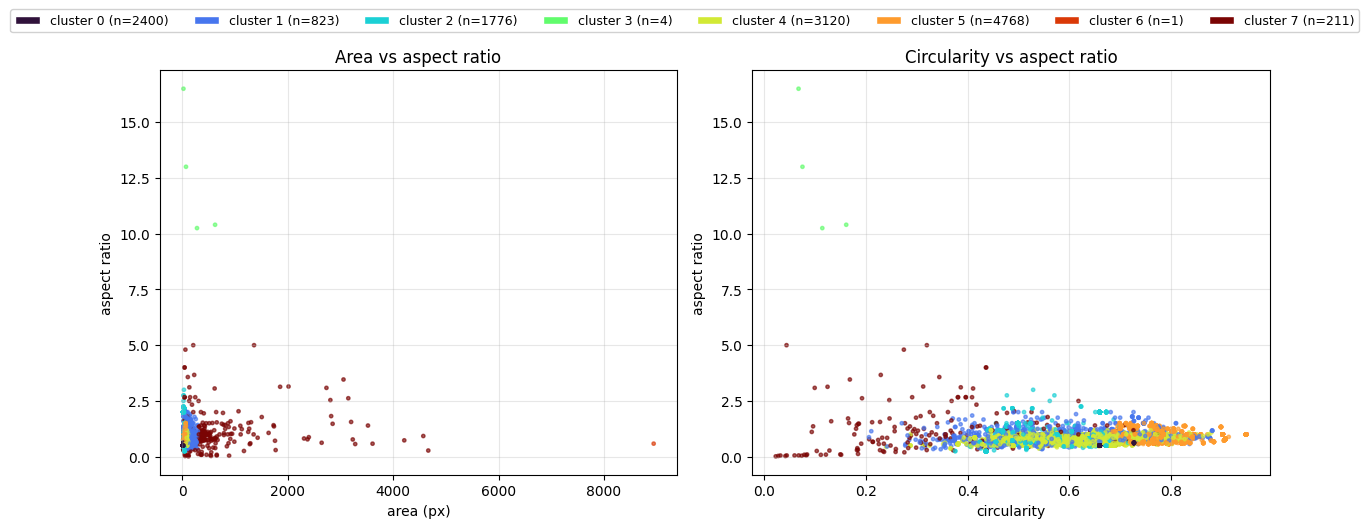

In [7]:
# 5.2 — Extra feature-space scatters

# aspect_ratio = width of box ÷ height of box
# (both in pixels; width is horizontal extent, height is vertical.)
# How to read the aspect ratio:
# 1.0 About as wide as tall (square-ish blob)
# < 1.0 Taller than wide (vertical streak)
# > 1.0 Wider than tall (horizontal streak)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter_kw = dict(c=labels, cmap=_cluster_cmap, norm=_cluster_norm, alpha=0.65, s=6)
axes[0].scatter(X[:, 0], X[:, 3], **scatter_kw)
axes[0].set_xlabel("area (px)")
axes[0].set_ylabel("aspect ratio")
axes[0].set_title("Area vs aspect ratio")
axes[0].grid(True, alpha=0.3)
axes[1].scatter(X[:, 2], X[:, 3], **scatter_kw)
axes[1].set_xlabel("circularity")
axes[1].set_ylabel("aspect ratio")
axes[1].set_title("Circularity vs aspect ratio")
axes[1].grid(True, alpha=0.3)
legend_handles = [
    Patch(
        facecolor=colors_rgb[c],
        edgecolor="white",
        label=f"cluster {c} (n={int((labels == c).sum())})",
    )
    for c in range(K)
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    
    bbox_to_anchor=(0.5, 1.06),
    ncol=K,
    fontsize=9,
    framealpha=0.9,
)
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_feature_scatters.png", bbox_inches="tight")
plt.show()

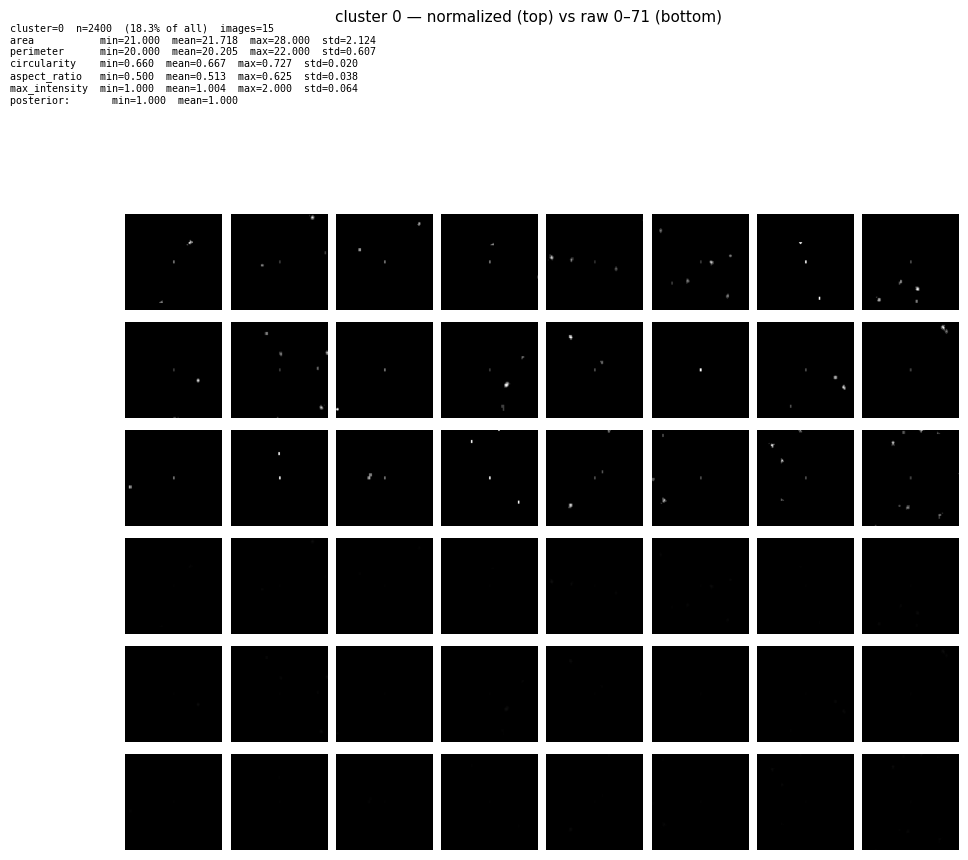

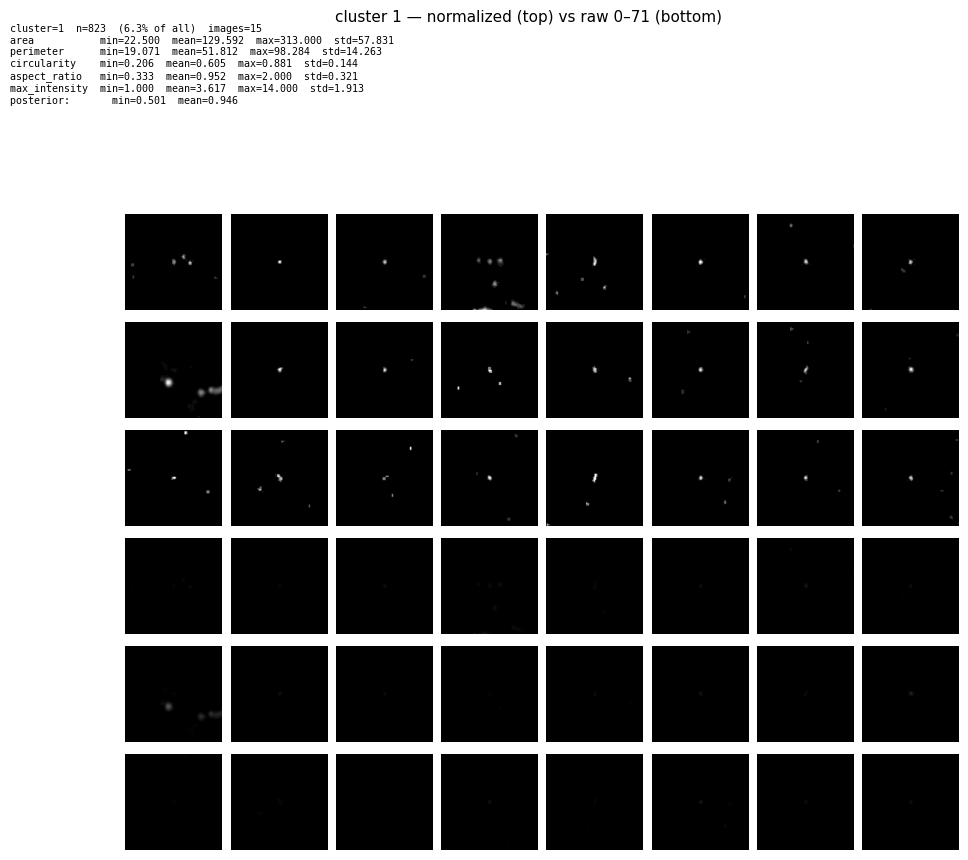

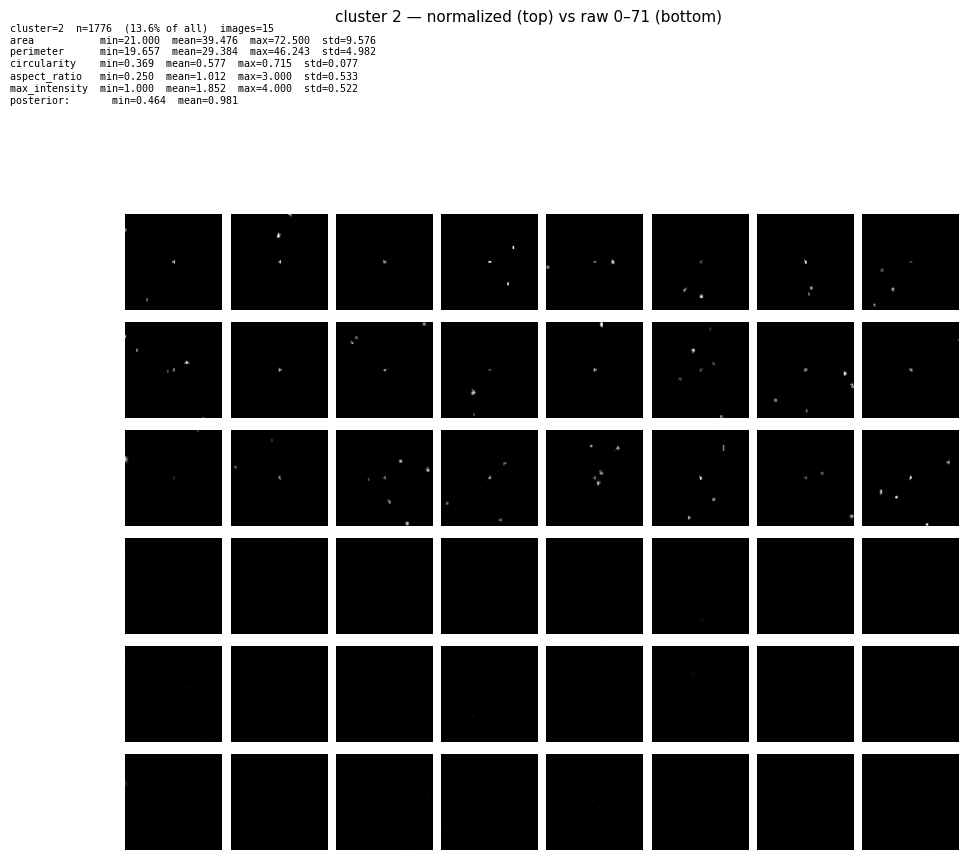

cluster 3: no valid patches for montage


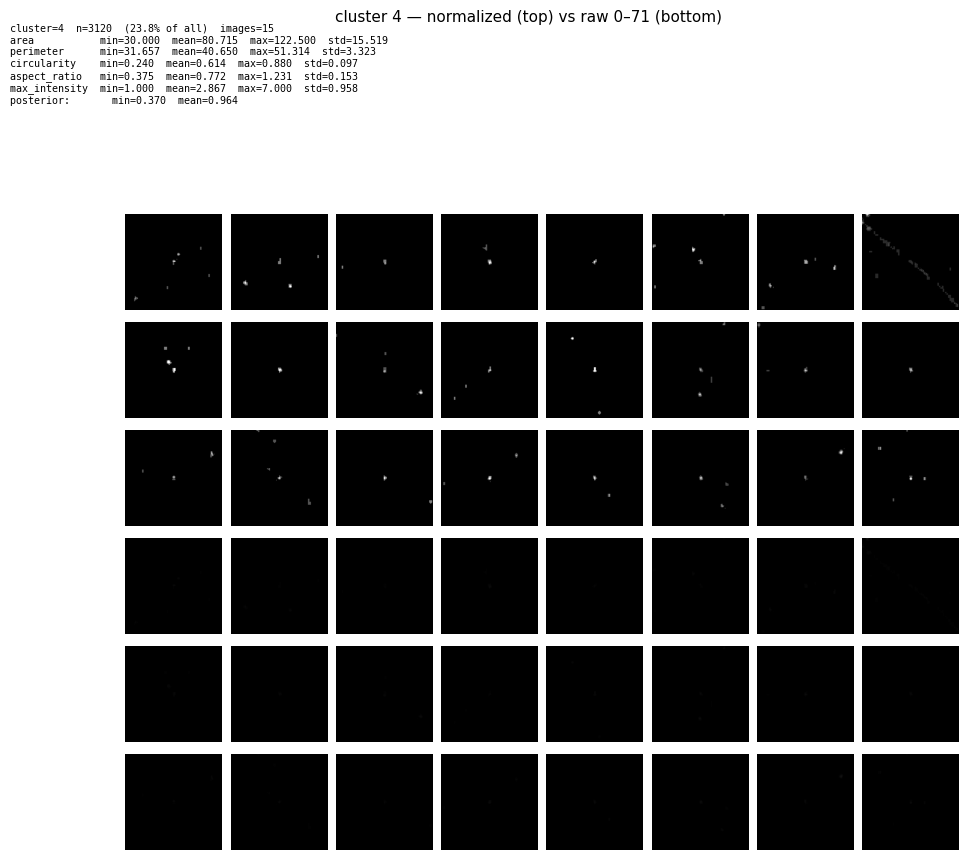

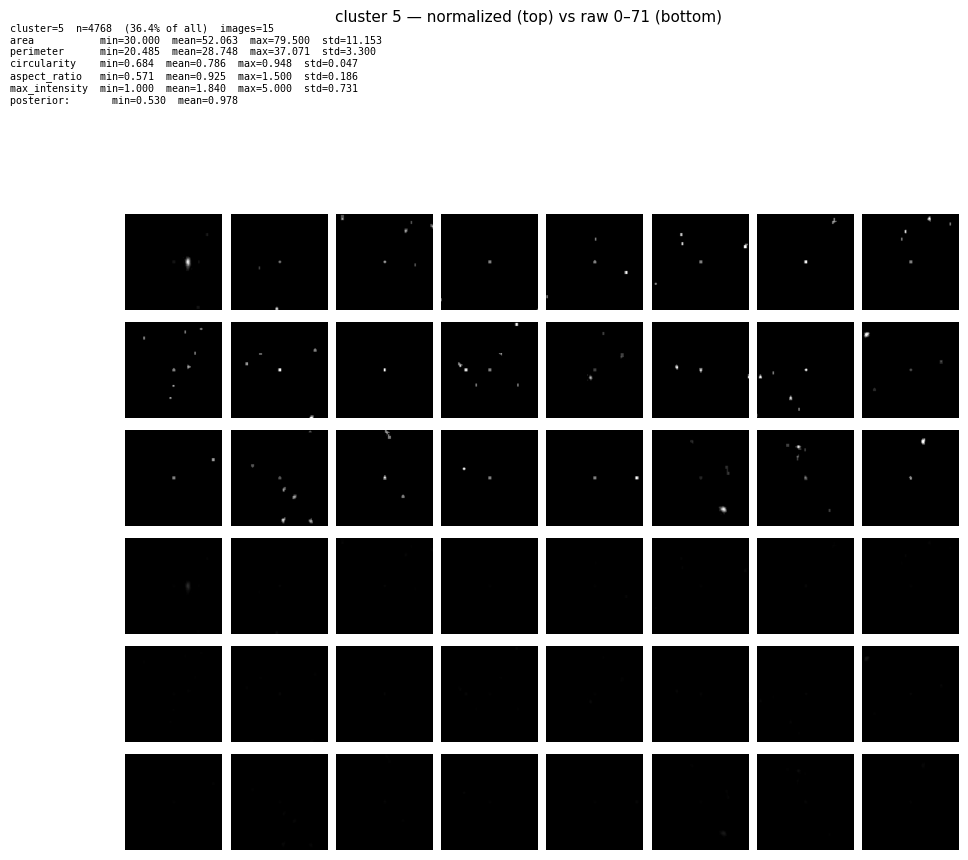

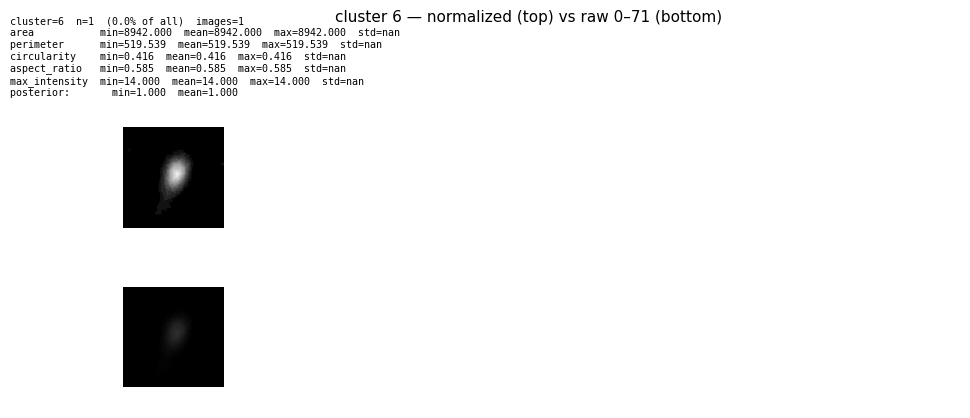

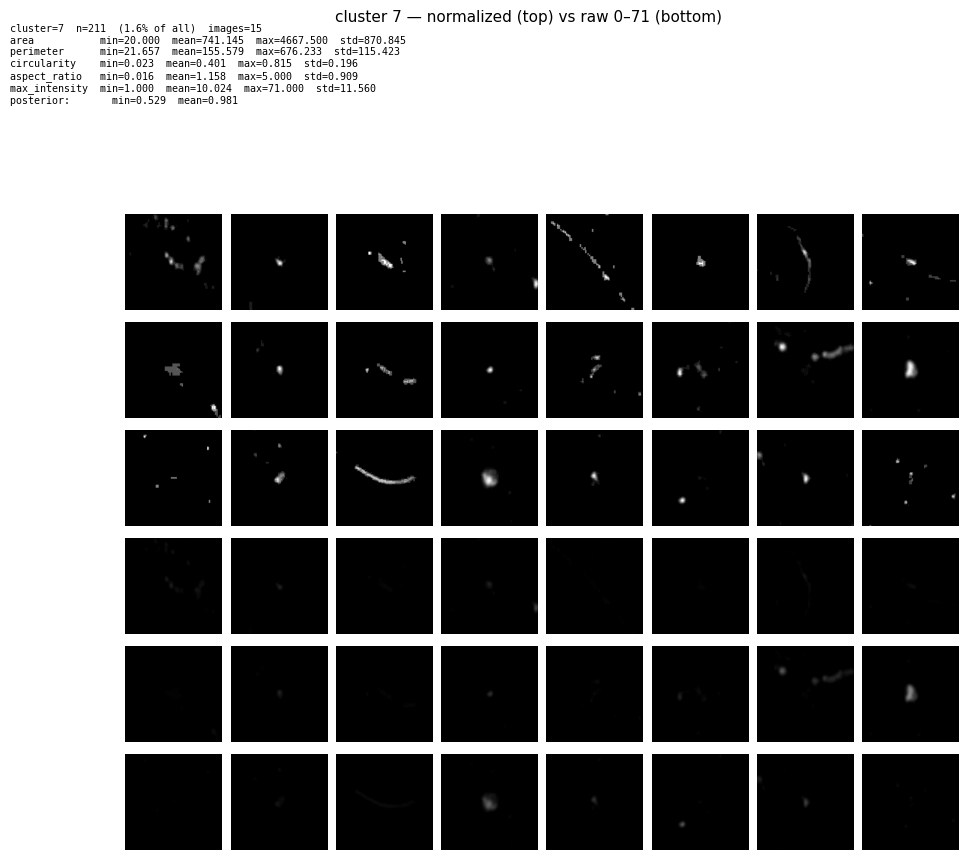

Saved cluster_*.png


In [8]:
# 5.3 — Per-cluster montages (normalized top / raw bottom)

# Posterior is the GMM’s assignment confidence: for each track, 
# the probability that it belongs to the cluster it was assigned to.
# Value	Interpretation
# ≈ 1.0 | Strong, unambiguous assignment
# ≈ 0.5 | Ambiguous — other clusters are similarly likely
# Low min in a cluster | Some members are borderline

def cluster_montage(c, n=MONTAGE_N):
    idx_all = np.where(meta["cluster"].to_numpy() == c)[0]
    idx = idx_all[meta.iloc[idx_all]["patch_valid"].to_numpy()]
    sub = meta.iloc[idx_all]
    stats_txt, stats_row = cluster_stats_block(sub, c)
    if len(idx) == 0:
        print(f"cluster {c}: no valid patches for montage")
        return stats_row
    pick = np.random.choice(idx, min(n, len(idx)), replace=False)
    cols = MONTAGE_COLS
    rows = int(np.ceil(len(pick) / cols))
    fig_h = 2 * rows * 1.25 + 2.0
    fig, axes = plt.subplots(2 * rows, cols, figsize=(cols * 1.35, fig_h))
    axes = np.atleast_2d(axes)
    for ax in np.ravel(axes):
        ax.axis("off")
    for j, gi in enumerate(pick):
        vi = global_to_valid[gi]
        r, col = divmod(j, cols)
        axes[r, col].imshow(patches_norm[vi], cmap="gray", vmin=0, vmax=1)
        axes[rows + r, col].imshow(patches_stack[vi], cmap="gray", vmin=0, vmax=STEP36_RAW_VMAX)
    fig.suptitle(
        f"cluster {c} — normalized (top) vs raw 0–{STEP36_RAW_VMAX} (bottom)",
        fontsize=11,
        y=0.995,
    )
    fig.text(0.02, 0.98, stats_txt, fontsize=7.2, va="top", family="monospace", transform=fig.transFigure)
    plt.subplots_adjust(top=0.78, hspace=0.12, wspace=0.05)
    out = cfg.output_dir / f"cluster_{c}.png"
    fig.savefig(out, dpi=110, bbox_inches="tight")
    plt.show()
    return stats_row

for c in range(K):
    cluster_montage(c)
print("Saved cluster_*.png")

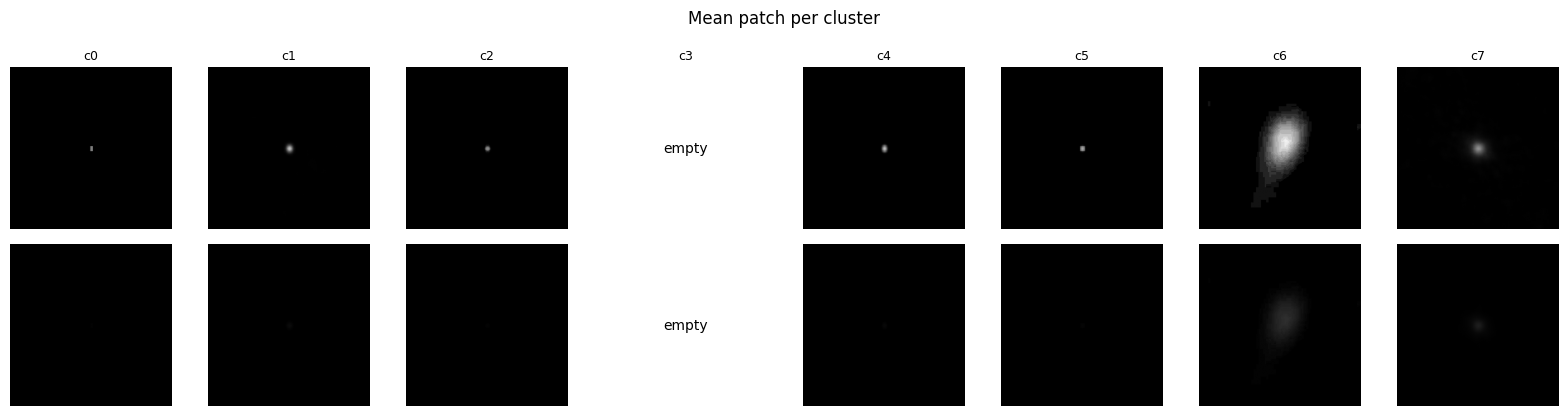

In [9]:
# 5.4 — Mean patch per cluster
fig, axes = plt.subplots(2, K, figsize=(2.0 * K, 4.2))
if K == 1:
    axes = np.array(axes).reshape(2, 1)
for c in range(K):
    idx_all = np.where(meta["cluster"].to_numpy() == c)[0]
    idx = idx_all[meta.iloc[idx_all]["patch_valid"].to_numpy()]
    axes[0, c].set_title(f"c{c}", fontsize=9)
    axes[1, c].axis("off")
    axes[0, c].axis("off")
    if len(idx) == 0:
        axes[0, c].text(0.5, 0.5, "empty", ha="center", va="center")
        axes[1, c].text(0.5, 0.5, "empty", ha="center", va="center")
        continue
    vi = [global_to_valid[gi] for gi in idx]
    norm_mean = patches_norm[vi].mean(axis=0)
    raw_mean = patches_stack[vi].mean(axis=0)
    axes[0, c].imshow(norm_mean, cmap="gray", vmin=0, vmax=1)
    axes[1, c].imshow(raw_mean, cmap="gray", vmin=0, vmax=STEP36_RAW_VMAX)
axes[0, 0].set_ylabel("norm mean", fontsize=9)
axes[1, 0].set_ylabel(f"raw mean\n0–{STEP36_RAW_VMAX}", fontsize=9)
fig.suptitle("Mean patch per cluster")
plt.tight_layout()
fig.savefig(cfg.output_dir / "gmm_cluster_mean_patches.png", dpi=110, bbox_inches="tight")
plt.show()

/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/fc/miniforge3/envs/pytmetalbeta/lib/python3.13/site-pack

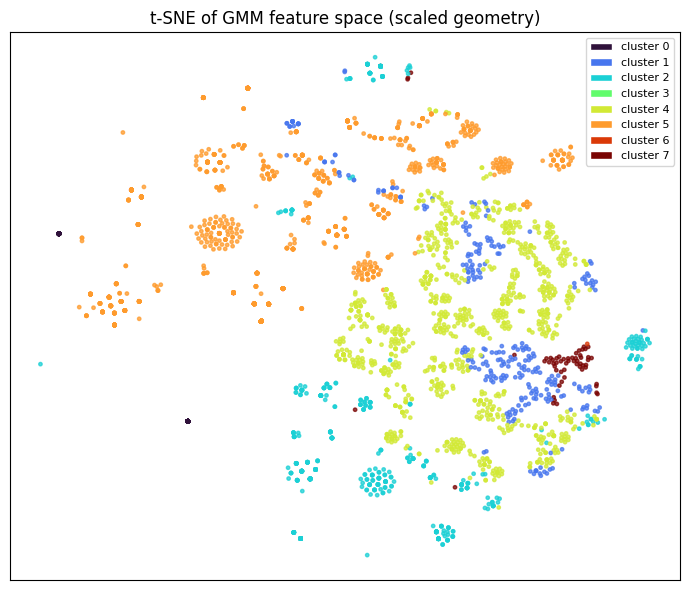

In [10]:
# 5.5 — t-SNE of scaled feature space

# Each dot is one detected track (blob). 
# Its position is not (area, circularity) directly — it’s a 2D embedding 
# built from the 4 scaled GMM features:
# area
# perimeter
# circularity
# aspect ratio

sub_n = min(4000, len(X_scaled))
sidx = np.random.choice(len(X_scaled), sub_n, replace=False)
Zp = PCA(n_components=min(4, X_scaled.shape[1]), random_state=cfg.random_state).fit_transform(X_scaled[sidx])
emb2d = TSNE(n_components=2, perplexity=30, init="pca", random_state=cfg.random_state).fit_transform(Zp)
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    emb2d[:, 0],
    emb2d[:, 1],
    c=meta["cluster"].to_numpy()[sidx],
    cmap=_cluster_cmap,
    norm=_cluster_norm,
    s=6,
    alpha=0.75,
)
legend_handles = [
    Patch(facecolor=colors_rgb[c], edgecolor="white", label=f"cluster {c}")
    for c in range(K)
]
plt.legend(handles=legend_handles, loc="best", fontsize=8)
plt.title("t-SNE of GMM feature space (scaled geometry)")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_tsne.pdf", dpi=120, bbox_inches="tight")
plt.show()

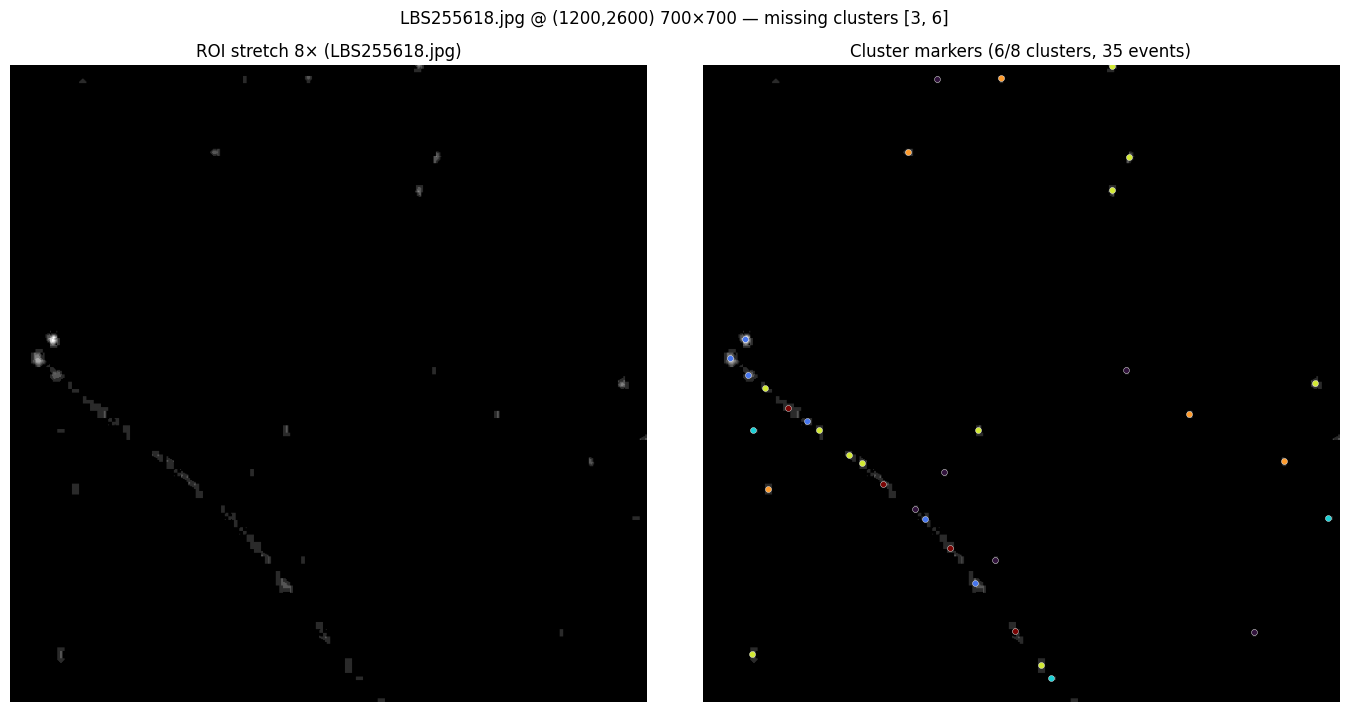

ROI: LBS255618.jpg  x0=1200  y0=2600  clusters=[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]  n=35


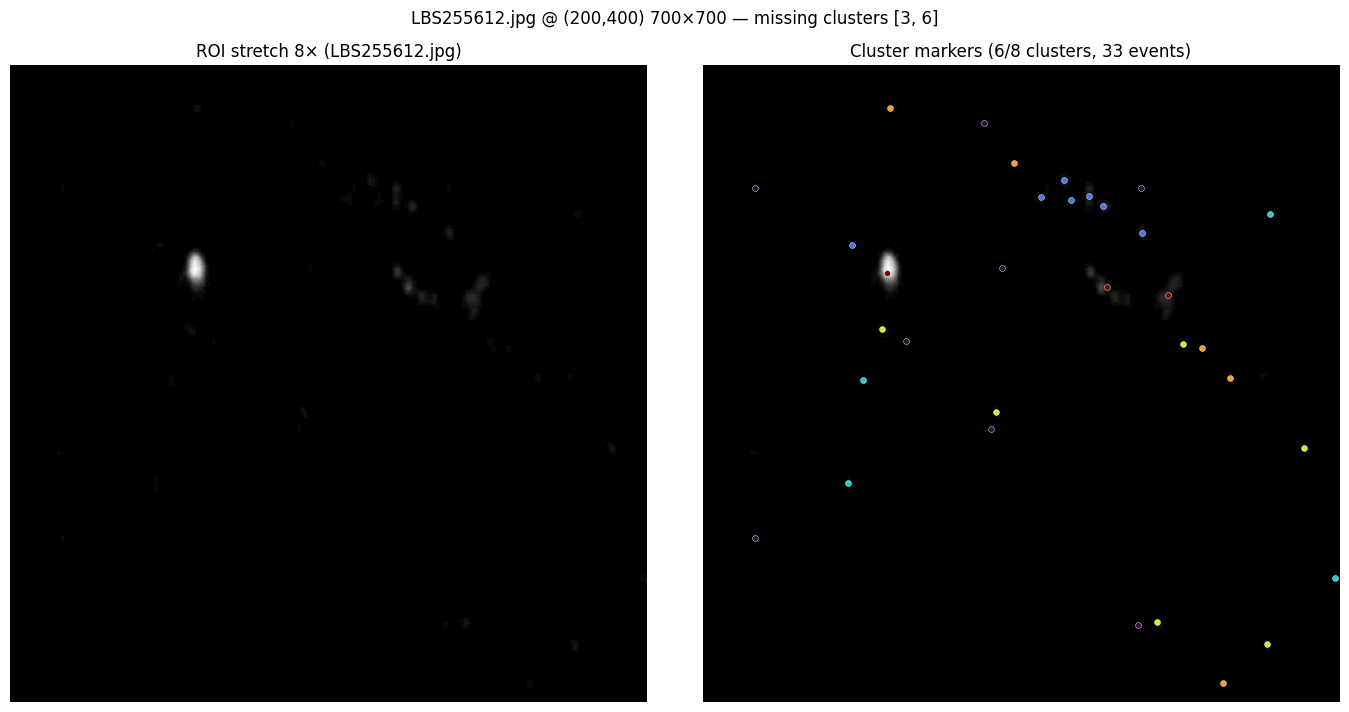

ROI: LBS255612.jpg  x0=200  y0=400  clusters=[np.int64(0), np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(7)]  n=33


In [11]:
# 5.6 — Dense ROI window with all clusters visible

def _pick_roi_all_clusters(meta_df, size, grid, n_clusters):
    best = (-1, -1, None, None, None, None)
    roi_lookup = {reg["path"].name: reg["roi"] for reg in image_registry}
    for img_name, grp in meta_df.groupby("image"):
        roi = roi_lookup[img_name]
        H, W = roi.shape
        if H < size or W < size:
            continue
        ys = np.arange(0, H - size, grid)
        xs = np.arange(0, W - size, grid)
        for y0 in ys:
            for x0 in xs:
                mask = (
                    (grp["cx"] >= x0)
                    & (grp["cx"] < x0 + size)
                    & (grp["cy"] >= y0)
                    & (grp["cy"] < y0 + size)
                )
                sub = grp.loc[mask]
                if sub.empty:
                    continue
                n_cl = sub["cluster"].nunique()
                n_cand = len(sub)
                key = (n_cl, n_cand)
                if key > best[:2]:
                    best = (n_cl, n_cand, img_name, int(x0), int(y0), sub)
    return best


def _plot_roi_cluster_window(img_name, x0, y0, size, save_path):
    """Stretch ROI + cluster markers for a fixed window (cross-run comparable)."""
    roi_lookup = {reg["path"].name: reg["roi"] for reg in image_registry}
    if img_name not in roi_lookup:
        print(f"Skip ROI plot: {img_name} not in image_registry")
        return
    roi = roi_lookup[img_name]
    H, W = roi.shape
    if x0 < 0 or y0 < 0 or x0 + size > W or y0 + size > H:
        raise ValueError(
            f"ROI window ({x0},{y0})+{size} out of bounds for {img_name} ({W}×{H})"
        )
    cands = meta.loc[
        (meta["image"] == img_name)
        & (meta["cx"] >= x0)
        & (meta["cx"] < x0 + size)
        & (meta["cy"] >= y0)
        & (meta["cy"] < y0 + size)
    ]
    crop = roi[y0 : y0 + size, x0 : x0 + size]
    stretch = np.clip(crop.astype(int) * 8, 0, 255)
    clusters_present = sorted(cands["cluster"].unique()) if len(cands) else []
    n_cl = len(clusters_present)
    n_cand = len(cands)
    missing = [c for c in range(K) if c not in clusters_present]
    status = "all clusters present" if not missing else f"missing clusters {missing}"

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(stretch, cmap="gray")
    ax[0].set_title(f"ROI stretch 8× ({img_name})")
    ax[0].axis("off")
    ax[1].imshow(stretch, cmap="gray")
    for _, r in cands.iterrows():
        ax[1].scatter(
            r["cx"] - x0,
            r["cy"] - y0,
            s=18,
            c=[colors_rgb[int(r["cluster"])]],
            edgecolors="white",
            linewidths=0.3,
        )
    ax[1].set_title(f"Cluster markers ({n_cl}/{K} clusters, {n_cand} events)")
    ax[1].axis("off")
    fig.suptitle(f"{img_name} @ ({x0},{y0}) {size}×{size} — {status}", y=1.01)
    plt.tight_layout()
    fig.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"ROI: {img_name}  x0={x0}  y0={y0}  clusters={clusters_present}  n={n_cand}")


best = _pick_roi_all_clusters(meta, ROI_WINDOW, 200, K)
n_cl, n_cand, img_name, x0, y0, _cands = best
if img_name is None:
    raise RuntimeError("No ROI window found for cluster overlay plot")
_plot_roi_cluster_window(
    img_name,
    x0,
    y0,
    ROI_WINDOW,
    cfg.output_dir / "gmm_all_clusters_roi.png",
)

# 5.6b — fixed comparison window (same geometry across runs)
_plot_roi_cluster_window(
    COMPARE_ROI_IMAGE,
    COMPARE_ROI_X0,
    COMPARE_ROI_Y0,
    ROI_WINDOW,
    cfg.output_dir / "gmm_compare_roi_LBS255612.png",
)

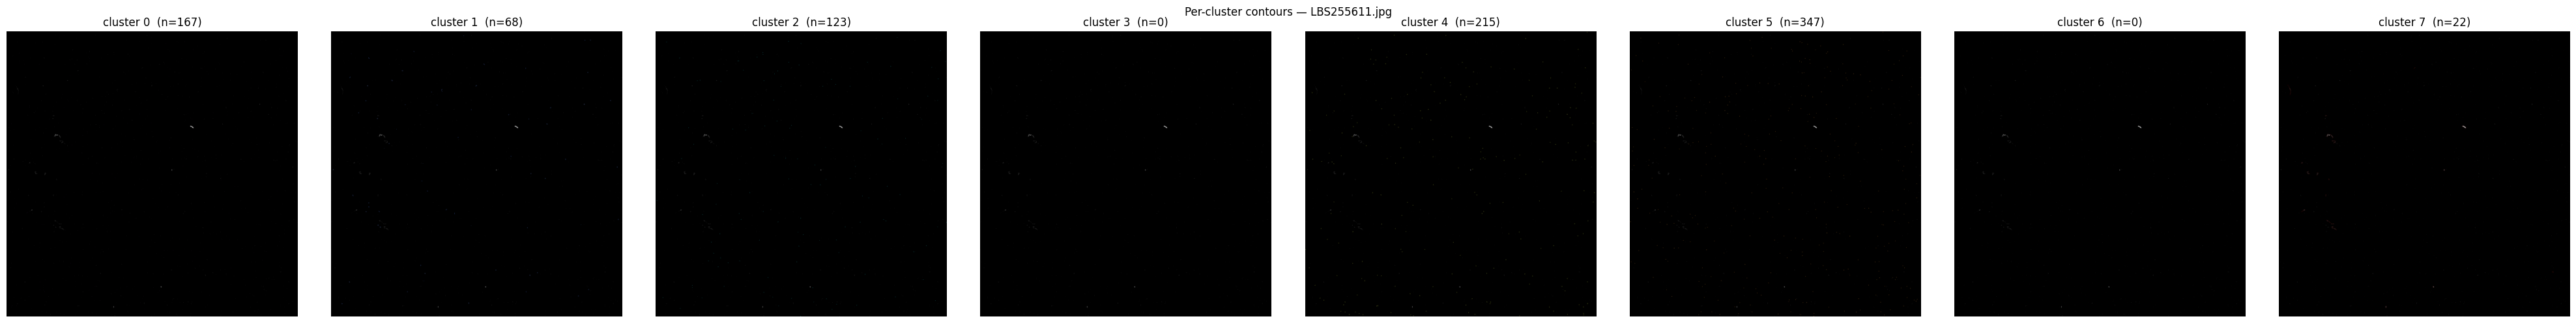

In [12]:
# 5.7 — Per-cluster spatial panels on sample image
if image_registry:
    sample = image_registry[0]
    start = sample["label_start"]
    end = start + sample["counts"]
    sample_labels = labels[start:end]
    roi_norm = cv2.normalize(sample["roi"], None, 0, 255, cv2.NORM_MINMAX)
    fig, axes = plt.subplots(1, K, figsize=(5 * K, 5))
    if K == 1:
        axes = [axes]
    for c in range(K):
        roi_color = cv2.cvtColor(roi_norm, cv2.COLOR_GRAY2BGR)
        for idx, cnt in enumerate(sample["contours"]):
            if sample_labels[idx] != c:
                continue
            cv2.drawContours(roi_color, [cnt], -1, colors_bgr[c], 1)
        n_c = int((sample_labels == c).sum())
        axes[c].imshow(cv2.cvtColor(roi_color, cv2.COLOR_BGR2RGB))
        axes[c].set_title(f"cluster {c}  (n={n_c})")
        axes[c].axis("off")
    fig.suptitle(f"Per-cluster contours — {sample['path'].name}")
    plt.tight_layout()
    plt.savefig(cfg.output_dir / "gmm_per_cluster_spatial.pdf", bbox_inches="tight")
    plt.show()

## Step 6 — Watershed split, saliency artifacts, count comparison

Two-pass flow: **GMM baseline** → watershed on large blobs in selected clusters → **saliency** artifact tagging (`area × max_intensity`) → per-image counts vs ImageJ `Summary.csv`.

Edit `WATERSHED_CLUSTERS`, `WS_METHOD`, and `ARTIFACT_CLUSTERS` in Step 0 after inspecting outputs below.

In [13]:
# 6.1 — Cluster profiles (mean area + saliency) to pick watershed clusters
meta_gmm = meta_gmm.copy()
meta_gmm["saliency"] = meta_gmm["area"] * meta_gmm["max_intensity"]
prof_gmm = meta_gmm.groupby("cluster").agg(
    n=("area", "size"),
    area=("area", "mean"),
    max_int=("max_intensity", "mean"),
    saliency=("saliency", "mean"),
)
display(prof_gmm.round(3))

ws_clusters = resolve_ws_clusters(
    meta_gmm, meta_gmm["cluster"].to_numpy(), cfg, WATERSHED_CLUSTERS or None
)
if WS_CLUSTER_FILTER:
    print(f"Watershed clusters (area >= {WS_MIN_AREA} px): {ws_clusters}")
else:
    print(f"Watershed: area-only mode (>= {WS_MIN_AREA} px), all clusters")
    ws_clusters = []

cfg.ws_min_area = WS_MIN_AREA
cfg.ws_min_fragment_area = WS_MIN_FRAGMENT_AREA
cfg.ws_cluster_filter = WS_CLUSTER_FILTER
cfg.ws_method = WS_METHOD

,n,area,max_int,saliency
cluster,,,,
0,2400,21.718,1.004,21.808
1,823,129.592,3.617,540.827
2,1776,39.476,1.852,75.938
3,4,250.250,6.500,1817.250
4,3120,80.715,2.867,238.300
5,4768,52.063,1.840,98.579
6,1,8942.000,14.000,125188.000
7,211,741.145,10.024,11872.237


Watershed: area-only mode (>= 160 px), all clusters


In [14]:
# 6.2 — Watershed method comparison (diagnostic on first image)
diag_reg = image_registry[0]
diag_labels = meta_gmm.loc[
    meta_gmm["image"] == diag_reg["path"].name, "cluster"
].to_numpy()
method_cmp = compare_watershed_methods(
    diag_reg["roi"], diag_reg["contours"], diag_labels, cfg, ws_clusters
)
method_df = pd.DataFrame(method_cmp).T
display(method_df)
print(f"Diagnostic image: {diag_reg['path'].name}  |  production WS_METHOD = {WS_METHOD}")

,n_candidates,n_split_parents,n_total_fragments,error
distance_peaks,38.0,26.0,130.0,NaN
h_minima,38.0,0.0,38.0,NaN
cv2_marker,38.0,16.0,78.0,NaN


Diagnostic image: LBS255611.jpg  |  production WS_METHOD = distance_peaks


In [15]:
# 6.3 — Apply watershed pass (re-predict clusters, no GMM re-fit)
meta_ws, X_ws, labels_ws, ws_stats = apply_watershed_pass(
    image_registry,
    meta_gmm,
    meta_gmm["cluster"].to_numpy(),
    gmm,
    scaler,
    cfg,
    ws_clusters,
)
meta_ws = meta_ws.copy()
meta_ws["cluster"] = labels_ws
print(ws_stats)

{'ws_clusters': [], 'n_parents_split': 228, 'n_new_fragments': 888, 'n_before': 13103, 'n_after': 13763}


In [16]:
# 6.4 — Saliency artifact tagging (override ARTIFACT_CLUSTERS in Step 0)
meta_ws["saliency"] = meta_ws["area"] * meta_ws["max_intensity"]
prof_ws, suggested = suggest_artifact_clusters(meta_ws, cfg.artifact_saliency_ratio)
display(prof_ws.round(3))

artifact_clusters = ARTIFACT_CLUSTERS if ARTIFACT_CLUSTERS is not None else suggested
# ARTIFACT_CLUSTERS = [0, 4, 5]  # manual override
meta_ws["is_track"] = ~meta_ws["cluster"].isin(artifact_clusters)
print("Using ARTIFACT_CLUSTERS =", artifact_clusters, "(override manually in Step 0)")
prof_ws.to_csv(cfg.output_dir / "gmm_cluster_saliency_profiles.csv")

,n,area,max_int,saliency,suggest_artifact
cluster,,,,,
0,2406,21.719,1.004,21.809,True
1,1004,126.400,4.368,552.058,False
2,1914,39.332,1.921,75.541,False
3,2,48.000,1.500,72.000,False
4,3278,80.957,2.889,233.905,False
5,4894,52.093,1.858,96.809,False
7,265,402.255,9.974,4011.922,False


Using ARTIFACT_CLUSTERS = [0] (override manually in Step 0)


,image,imagej_count,gmm_count,gmm_ws_count,gmm_ws_clean_count
0,LBS255611.jpg,795,942,1034,867
1,LBS255612.jpg,752,859,958,793
2,LBS255613.jpg,729,842,885,732
3,LBS255614.jpg,713,819,846,680
4,LBS255615.jpg,719,828,844,665
5,LBS255616.jpg,640,719,725,569
6,LBS255617.jpg,810,935,973,821
7,LBS255618.jpg,668,767,788,648
8,LBS255619.jpg,739,863,907,726
9,LBS255620.jpg,786,932,990,841


TOTALS: {'imagej_count': 11278, 'gmm_count': 13103, 'gmm_ws_count': 13763, 'gmm_ws_clean_count': 11357}


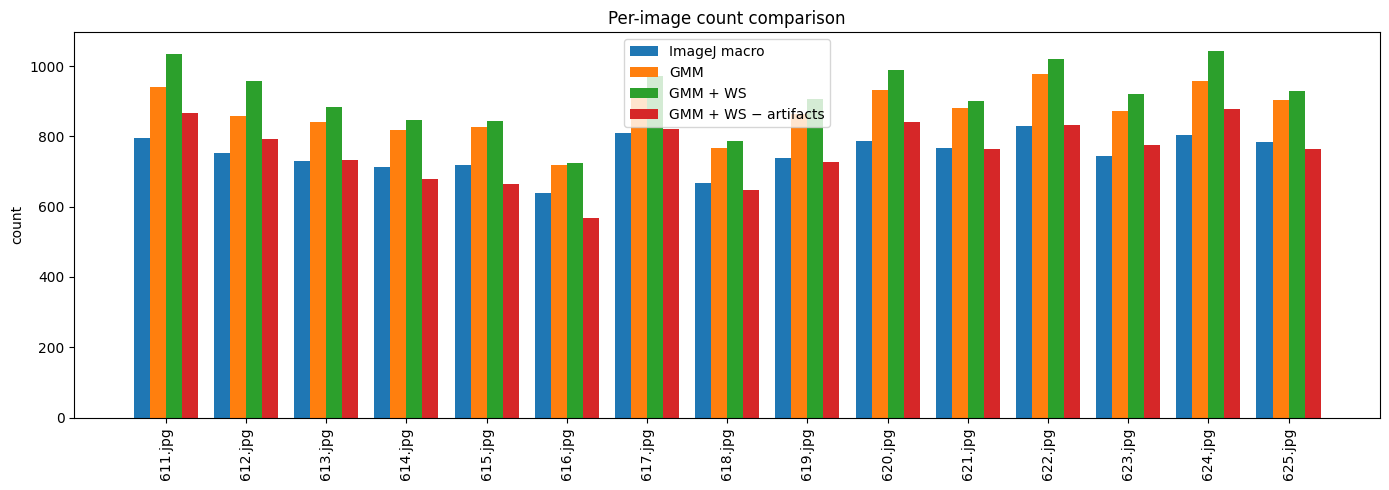

Total events (sum over all images):
  ImageJ macro: 11278
  GMM: 13103
  GMM + WS: 13763
  GMM + WS − artifacts: 11357
Saved /Users/fc/Library/CloudStorage/OneDrive-MuseoStoricodellaFisicaeCentroStudieRicercheEnricoFermi/acme/CREF/sourceforge/github/radon/gmm/outputs/gmm_count_comparison.csv


In [17]:
# 6.5 — Count comparison vs ImageJ Summary.csv
macro_map = load_macro_counts(cfg.macro_summary)
final_df = build_count_comparison(macro_map, meta_gmm, meta_ws, artifact_clusters)
final_df.to_csv(cfg.output_dir / "gmm_count_comparison.csv", index=False)
display(final_df)
print(
    "TOTALS:",
    final_df[["imagej_count", "gmm_count", "gmm_ws_count", "gmm_ws_clean_count"]].sum().astype(int).to_dict(),
)
save_count_comparison_plots(final_df, cfg.output_dir)

x = np.arange(len(final_df))
w = 0.2
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 1.5 * w, final_df["imagej_count"], w, label="ImageJ macro")
ax.bar(x - 0.5 * w, final_df["gmm_count"], w, label="GMM")
ax.bar(x + 0.5 * w, final_df["gmm_ws_count"], w, label="GMM + WS")
ax.bar(x + 1.5 * w, final_df["gmm_ws_clean_count"], w, label="GMM + WS − artifacts")
ax.set_xticks(x)
ax.set_xticklabels([n[-7:] for n in final_df["image"]], rotation=90)
ax.set_ylabel("count")
ax.legend()
ax.set_title("Per-image count comparison")
plt.tight_layout()
plt.savefig(cfg.output_dir / "gmm_count_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

_count_cols = {
    "imagej_count": "ImageJ macro",
    "gmm_count": "GMM",
    "gmm_ws_count": "GMM + WS",
    "gmm_ws_clean_count": "GMM + WS − artifacts",
}
_totals = final_df[list(_count_cols)].sum().astype(int)
print("Total events (sum over all images):")
for col, label in _count_cols.items():
    print(f"  {label}: {_totals[col]}")

print("Saved", cfg.output_dir / "gmm_count_comparison.csv")

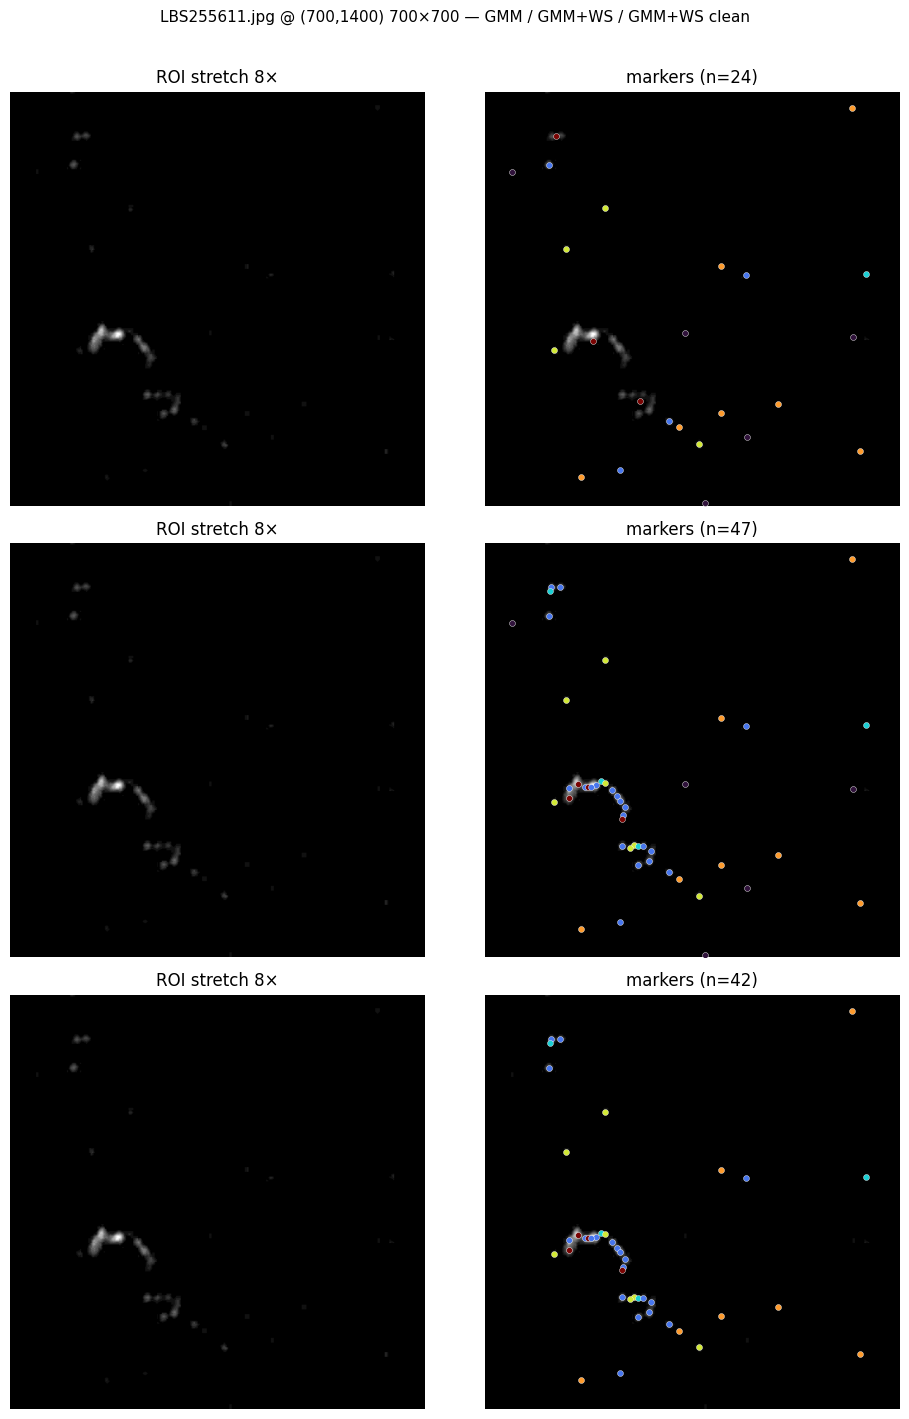

in ROI (700,1400,700): {'GMM': 24, 'GMM + WS': 47, 'GMM + WS clean': 42}


In [18]:
# 6.7 — Visual ROI comparison: GMM / GMM+WS / GMM+WS clean
roi_lookup = {reg["path"].name: reg["roi"] for reg in image_registry}
roi_vis = roi_lookup[VISUAL_COMPARE_ROI_IMAGE]
counts_vis, fig_vis = plot_roi_three_variants(
    roi_vis,
    meta_gmm,
    meta_ws,
    VISUAL_COMPARE_ROI_IMAGE,
    VISUAL_COMPARE_ROI_X0,
    VISUAL_COMPARE_ROI_Y0,
    VISUAL_COMPARE_ROI_SIZE,
    colors_rgb,
    save_path=cfg.output_dir / "gmm_roi_compare_LBS255611.png",
)
plt.show()
print(
    f"in ROI ({VISUAL_COMPARE_ROI_X0},{VISUAL_COMPARE_ROI_Y0},{VISUAL_COMPARE_ROI_SIZE}):",
    counts_vis,
)